<a href="https://colab.research.google.com/github/LaibaAkbarTaj/Machine-Learning/blob/main/CNN_Rice_Image_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install split-folders tensorflow kagglehub

#### Importing all the Packages/Libraries


In [ ]:
import os
import kagglehub
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

#### Downloading Dataset

In [ ]:
# Download dataset
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Dataset Path: /kaggle/input/dog-and-cat-classification-dataset


In [ ]:
os.listdir(path)

['PetImages']

#### Spliting it to Folders Test,Train,Val

In [ ]:
input_folder = path+"/PetImages"
output_folder = "data_split"

import splitfolders

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15)  # Train, Val, Test
)

Copying files: 24998 files [00:35, 701.51 files/s]


In [ ]:
IMG_SIZE = 150
BATCH_SIZE = 32

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 17498 images belonging to 4 classes.
Found 3748 images belonging to 4 classes.
Found 3752 images belonging to 4 classes.


### CNN Model Layers

Conv2D → detects patterns/features in the image (edges, textures, shapes) using filters.

MaxPooling2D → reduces spatial size of feature maps, keeping important info and lowering computation.

Flatten + Dense → converts features into a 1D vector and learns combinations to classify images.

Dropout → randomly ignores some neurons during training to prevent overfitting.

Last Dense(1, sigmoid) → outputs probability for binary classification (0 or 1).

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model.compile(...) → sets how the model learns:

optimizer='adam' → updates weights using Adam optimizer.

loss='binary_crossentropy' → measures error for binary classification.

metrics=['accuracy'] → tracks accuracy during training.

model.summary() → prints the structure of your CNN, showing layers, output shapes, and number of parameters.

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
519/547 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - accuracy: 0.5521 - loss: 0.7225

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


547/547 ━━━━━━━━━━━━━━━━━━━━ 140s 247ms/step - accuracy: 0.5545 - loss: 0.7195 - val_accuracy: 0.7020 - val_loss: 0.5868
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 133s 243ms/step - accuracy: 0.6907 - loss: 0.5861 - val_accuracy: 0.7649 - val_loss: 0.5030
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 128s 234ms/step - accuracy: 0.7451 - loss: 0.5215 - val_accuracy: 0.7919 - val_loss: 0.4459
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 127s 232ms/step - accuracy: 0.7765 - loss: 0.4713 - val_accuracy: 0.7882 - val_loss: 0.4627
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 127s 232ms/step - accuracy: 0.7955 - loss: 0.4388 - val_accuracy: 0.8116 - val_loss: 0.4109
Epoch 6/10
 10/547 ━━━━━━━━━━━━━━━━━━━━ 2:44 306ms/step - accuracy: 0.8023 - loss: 0.4107

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.8288 - loss: 0.3843
Test Accuracy: 0.8336886763572693


In [ ]:
!pip install tensorflow

In [ ]:
# load an model
from tensorflow.keras.models import load_model

model = load_model("dog_cat_cnn_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[0.91820604]


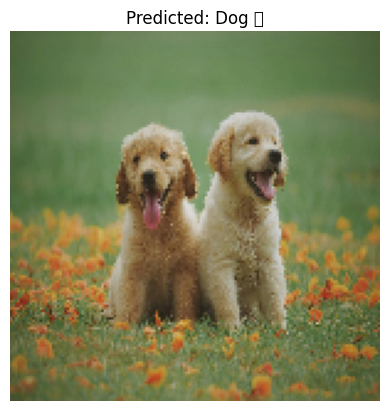

In [ ]:
from tensorflow.keras.preprocessing import image

sample_image_path = "dog.jpg"

img = image.load_img(sample_image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

print(prediction[0])
if prediction[0][0] > 0.5:
    plt.title("Predicted: Dog 🐶")
else:
    plt.title("Predicted: Cat 🐱")

plt.show()

In [ ]:
model.save("dog_cat_cnn_model.keras")

# Rice Dataset CNN Model

In [ ]:
# Download dataset
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'rice-image-dataset' dataset.
Dataset Path: /kaggle/input/rice-image-dataset


In [ ]:
os.listdir(path)

['Rice_Image_Dataset']

In [ ]:
import os
import splitfolders

# Go inside rice folder
input_folder = os.path.join(path, "Rice_Image_Dataset")

output_folder = "rice_split"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.8, 0.2, 0.0)
)

print("Data split successfully!")

Copying files: 72950 files [07:16, 219.87 files/s]

In [ ]:
!ls rice_split/test

In [ ]:
IMG_SIZE = 150
BATCH_SIZE = 32

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 19998 files belonging to 2 classes.
Using 15999 files for training.
Found 4998 files belonging to 2 classes.
Using 999 files for validation.
Found class names: ['Cat', 'Dog']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the input shape (based on your image_dataset_from_directory setup)
INPUT_SHAPE = (150, 150, 3) # Height, Width, Color Channels (RGB)
NUM_CLASSES = 5          # You have 5 classes

#### MaxPooling2D reduces the spatial size of feature maps by taking the maximum value from each small region, keeping the strongest features while lowering computation.

#### In Conv2D(32, (3,3)), 32 means the number of filters (kernels) the layer will learn.

That means the layer will produce 32 different feature maps, each detecting a different pattern (like edges, textures, shapes, etc.).

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(264, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Display the model structure
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 59, 59, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 222784)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │    14,258,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,314,690 (54.61 MB)

 Trainable params: 14,314,690 (54.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
import os

# 1. Define the directory to save the checkpoints
checkpoint_dir = './training_checkpoints_cnn'
os.makedirs(checkpoint_dir, exist_ok=True) # Create the folder if it doesn't exist

# 2. Define the filepath for the model files
# The format includes epoch number and the validation loss/accuracy
checkpoint_filepath = os.path.join(
    checkpoint_dir,
    'rice_cnn_model_{epoch:02d}-{val_accuracy:.4f}.keras'
)

# 3. Create the ModelCheckpoint callback
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,       # Set to True if you only want to save weights
    monitor='val_accuracy',        # Metric to monitor (e.g., 'val_loss' or 'val_accuracy')
    mode='max',                    # 'max' means we look for the highest val_accuracy
    save_best_only=True,           # Only save a model if 'val_accuracy' improves
    verbose=1                      # Log when a new best model is saved
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Starting model training with Checkpoints...
Epoch 1/5
225/500 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.4858 - loss: 130.3209

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) INVALID_ARGUMENT:  Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]]
	 [[IteratorGetNext/_2]]
  (1) INVALID_ARGUMENT:  Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]]
0 successful operations.
0 derived errors ignored. [Op:__inference_multi_step_on_iterator_215920]

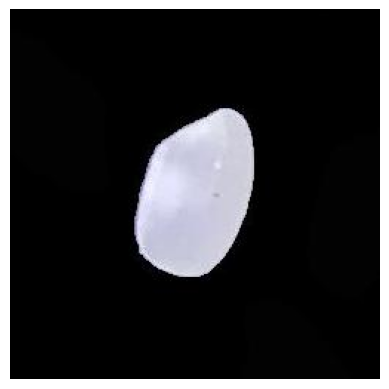

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Arborio: 0.338
Basmati: 0.097
Ipsala: 0.066
Jasmine: 0.223
Karacadag: 0.275


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

image_path = "Karacadag.jpg"

img = tf.keras.utils.load_img(image_path, target_size=(250,250))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = tf.expand_dims(img_array, 0)

img_array = img_array / 255.0  # scale pixels 0-1 for model

# 6️⃣ Show image preview
plt.imshow(img)
plt.axis('off')
plt.show()

preds = model.predict([img_array])[0]
for i, name in enumerate(train_ds.class_names):
    print(f"{name}: {preds[i]:.3f}")